In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# Path to your Excel training data
# (change this to the actual path/filename)
TRAINING_XLSX = "models/trevor_data.xlsx"

# Input columns must match the component labels / order used in DesignSpace
INPUT_COLS = ["Ti", "V", "Nb", "Mo", "Hf", "Ta", "W"]

# Target columns in your Excel sheet
TARGET_COLS = [
    "PROP RT Therm Cond (W/(mK))",
    "Sconf",
]

# Where to save the trained RF and scalers
OUTPUT_DIR = "models/TiVNbMoHfTaW_Max_S_Max_TCond"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUTPUT_DIR, "RFR_best_model.pkl")
X_SCALER_PATH = os.path.join(OUTPUT_DIR, "x_scaler.pkl")
Y_SCALER_PATH = os.path.join(OUTPUT_DIR, "y_scaler.pkl")

In [4]:
# If your data is on a specific sheet, pass sheet_name="Sheet1" (or the right name).
df = pd.read_excel(TRAINING_XLSX)  # , sheet_name="Sheet1"

print("Columns in Excel file:")
print(df.columns.tolist())
display(df.head())

# Extract inputs (X) and targets (y)
X_raw = df[INPUT_COLS].to_numpy(dtype=float)
y_raw = df[TARGET_COLS].to_numpy(dtype=float)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

Columns in Excel file:
['Unnamed: 0', 'Ti', 'V', 'Nb', 'Mo', 'Hf', 'Ta', 'W', 'System Type', 'Unnamed: 0.2', 'System Size', 'PROP ST (K)', 'PROP LT (K)', 'PROP RT Density (g/cm3)', 'PROP RT Elec Resi (ohm m)', 'PROP RT Heat Cap (J/(mol K))', 'PROP RT Therm Cond (W/(mK))', 'PROP RT Therm Diff (m2/s)', 'EQ 25C MAX BCC', 'EQ 25C MAX any', 'EQ 700C MAX BCC', 'EQ 800C MAX BCC', 'EQ 900C MAX BCC', 'EQ 1000C MAX BCC', 'EQ 1000C THCD (W/mK)', 'Melting Point (°C)_Avg', 'Melting Point (°C)_Var', 'Sconf', 'Solidification Range (K)', 'EQ 25C MAX NON-BCC', 'VASP-PAW-GGA LSE_Avg', 'VASP-PAW-GGA LSE_Var', 'SGTE LSE_Avg', 'SGTE LSE_Var', 'Allen EN_Avg', 'Allen EN_Var', 'Pauling EN_Avg', 'Pauling EN_Var', 'Density_Avg', 'Density_Var', 'Atomic Weight_Avg', 'Atomic Weight_Var', 'Valence e_Avg', 'Valence e_Var', 'IE_Avg', 'IE_Var', 'Specific Heat_Avg', 'Specific Heat_Var', 'Metallic Radius_Avg', 'Metallic Radius_Var', 'Shear Modulus_Avg', 'Shear Modulus_Var', 'Total Electrons_Avg', 'Total Electrons_Var', 

,Unnamed: 0,Ti,V,Nb,Mo,Hf,Ta,W,System Type,Unnamed: 0.2,...,Atomic Planar Density_Var,C_11_Avg,C_11_Var,C_12_Avg,C_12_Var,C'_Avg,C'_Var,Bulk Modulus (GPa)_Avg,Bulk Modulus (GPa)_Var,Pugh Ratio
0,500,0.05,0.000,0.575,0.100,0.0,0.225,0.050,17,77984,...,5.178468,16.650,39.770938,36.150,94.433191,-9.7500,31.358611,186.75,37.972852,3.132075
1,682,0.10,0.000,0.475,0.100,0.0,0.325,0.000,58,96328,...,5.697076,22.800,45.777287,41.100,95.001526,-9.1500,31.652843,179.75,30.289231,3.160440
2,809,0.05,0.000,0.600,0.050,0.0,0.225,0.075,17,80189,...,4.271883,11.400,34.318217,20.550,70.249181,-4.5750,22.844734,187.25,41.652581,3.195392
3,139,0.00,0.050,0.600,0.075,0.0,0.200,0.075,16,76428,...,5.118709,8.875,27.714786,36.350,96.610183,-13.7375,36.451507,190.50,38.791107,3.173678
4,766,0.05,0.025,0.550,0.125,0.0,0.250,0.000,28,93443,...,5.914301,19.775,41.875104,50.425,108.592792,-15.3250,38.319471,181.75,26.822332,3.215391


X_raw shape: (1000, 7)
y_raw shape: (1000, 2)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)

X_train_scaled shape: (800, 7)
y_train_scaled shape: (800, 2)


In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_scaled, y_train_scaled)

# Evaluate on test set (in original units)
y_pred_test_scaled = rf.predict(X_test_scaled)
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)

therm_cond_true = y_test[:, 0]
density_true = y_test[:, 1]
therm_cond_pred = y_pred_test[:, 0]
density_pred = y_pred_test[:, 1]

r2_tc = r2_score(therm_cond_true, therm_cond_pred)
r2_rho = r2_score(density_true, density_pred)

rmse_tc = mean_squared_error(therm_cond_true, therm_cond_pred)
rmse_rho = mean_squared_error(density_true, density_pred)

print(f"R^2 Therm Cond: {r2_tc:.3f}, RMSE: {rmse_tc:.3f} W/(mK)")
print(f"R^2 Density:    {r2_rho:.3f}, RMSE: {rmse_rho:.3f} g/cm³")

R^2 Therm Cond: 0.986, RMSE: 0.628 W/(mK)
R^2 Density:    0.868, RMSE: 0.002 g/cm³


In [7]:
joblib.dump(rf, MODEL_PATH)
joblib.dump(x_scaler, X_SCALER_PATH)
joblib.dump(y_scaler, Y_SCALER_PATH)

print("Saved RF model to:", MODEL_PATH)
print("Saved x_scaler to:", X_SCALER_PATH)
print("Saved y_scaler to:", Y_SCALER_PATH)

Saved RF model to: models/TiVNbMoHfTaW_Max_S_Max_TCond\RFR_best_model.pkl
Saved x_scaler to: models/TiVNbMoHfTaW_Max_S_Max_TCond\x_scaler.pkl
Saved y_scaler to: models/TiVNbMoHfTaW_Max_S_Max_TCond\y_scaler.pkl


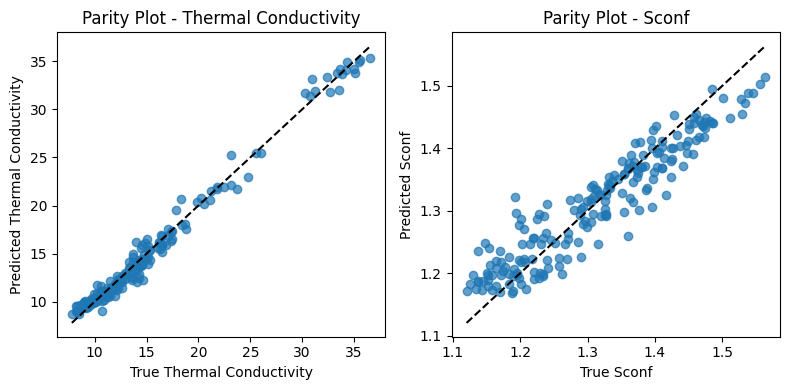

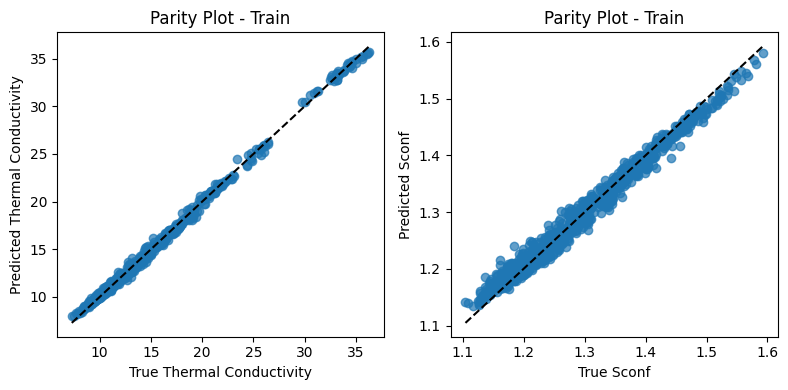

KeyboardInterrupt: 

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import itertools

# == Helper: Score function ==
def score_fn(Y):
    E = Y[:, 0]
    H = Y[:, 1]
    # Min-max normalize over current data
    E_norm = (E - E.min()) / (E.max() - E.min() + 1e-12)
    H_norm = (H - H.min()) / (H.max() - H.min() + 1e-12)
    return E_norm * H_norm

# == 1. Parity plots on test data ==
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(therm_cond_true, therm_cond_pred, alpha=0.7)
plt.plot([therm_cond_true.min(), therm_cond_true.max()],
         [therm_cond_true.min(), therm_cond_true.max()], 'k--')
plt.xlabel("True Thermal Conductivity")
plt.ylabel("Predicted Thermal Conductivity")
plt.title("Parity Plot - Thermal Conductivity")

plt.subplot(1,2,2)
plt.scatter(density_true, density_pred, alpha=0.7)
plt.plot([density_true.min(), density_true.max()],
         [density_true.min(), density_true.max()], 'k--')
plt.xlabel("True Sconf")
plt.ylabel("Predicted Sconf")
plt.title("Parity Plot - Sconf")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parity_test.png"), dpi=150)
plt.show()

# == 2. Parity plots on training data ==
y_pred_train_scaled = rf.predict(X_train_scaled)
y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)
therm_cond_true_tr = y_train[:, 0]
density_true_tr = y_train[:, 1]
therm_cond_pred_tr = y_pred_train[:, 0]
density_pred_tr = y_pred_train[:, 1]

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(therm_cond_true_tr, therm_cond_pred_tr, alpha=0.7)
plt.plot([therm_cond_true_tr.min(), therm_cond_true_tr.max()],
         [therm_cond_true_tr.min(), therm_cond_true_tr.max()], 'k--')
plt.xlabel("True Thermal Conductivity")
plt.ylabel("Predicted Thermal Conductivity")
plt.title("Parity Plot - Train")

plt.subplot(1,2,2)
plt.scatter(density_true_tr, density_pred_tr, alpha=0.7)
plt.plot([density_true_tr.min(), density_true_tr.max()],
         [density_true_tr.min(), density_true_tr.max()], 'k--')
plt.xlabel("True Sconf")
plt.ylabel("Predicted Sconf")
plt.title("Parity Plot - Train")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parity_train.png"), dpi=150)
plt.show()

# == 3. Predict the whole composition grid; find score_fn max ==
COMPONENTS = [
    ("Ti", 0.0,   0.35),
    ("V",  0.0,   0.50),
    ("Nb", 0.225, 0.675),
    ("Mo", 0.0,   0.125),
    ("Hf", 0.0,   0.125),
    ("Ta", 0.0,   0.45),
    ("W",  0.0,   0.125),
]
comp_names = [c[0] for c in COMPONENTS]
comp_ranges = [np.arange(c[1], c[2]+0.0001, 0.025) for c in COMPONENTS]

# -- Generate all combinations; enforce sum == 1 constraint (if needed) --
grid_pts = []
for vals in itertools.product(*comp_ranges):
    if np.isclose(sum(vals), 1.0, atol=0.01):   # composition must sum to 1
        grid_pts.append(vals)
grid_pts = np.array(grid_pts)
print(f"Grid points used: {len(grid_pts)}")

# -- Predict properties at the grid --
X_grid_scaled = x_scaler.transform(grid_pts)
Y_grid_scaled = rf.predict(X_grid_scaled)
Y_grid = y_scaler.inverse_transform(Y_grid_scaled)

# -- Calculate score at all points --
score = score_fn(Y_grid)

# -- Find argmax --
max_idx = np.argmax(score)
max_score = score[max_idx]
max_comp = grid_pts[max_idx].round(3)
max_props = Y_grid[max_idx].round(5)
print(f"Maximum score: {max_score:.4f}")
print("At composition:")
for c,val in zip(comp_names, max_comp):
    print(f"  {c}: {val}")
print("Predicted properties (Thermal Conductivity, Sconf):", max_props)

# == Save summary ==
with open(os.path.join(OUTPUT_DIR, "max_score.txt"), "w") as f:
    f.write(f"Maximum score: {max_score:.4f}\n")
    for c,val in zip(comp_names, max_comp):
        f.write(f"{c}: {val}\n")
    f.write("Predicted properties (Thermal Conductivity, Sconf): {}\n".format(max_props.tolist()))

# == 4. Visualize objectives and score in composition space ==
# Choose 2D slices to plot -- let's plot vs. Nb and Ta, others fixed at min
fixed_idx = [i for i in range(len(COMPONENTS)) if comp_names[i] not in ["Nb","Ta"]]
# We'll fix these to their minimum
fixed_vals = [COMPONENTS[i][1] for i in fixed_idx]
nb_idx = comp_names.index("Nb")
ta_idx = comp_names.index("Ta")
nb_vals = comp_ranges[nb_idx]
ta_vals = comp_ranges[ta_idx]
nt_grid = []
for nb in nb_vals:
    for ta in ta_vals:
        vals = fixed_vals.copy()
        vals.insert(nb_idx, nb)
        vals.insert(ta_idx, ta)
        # Reorder to full 7-component vector
        full_vals = []
        fi=0
        for i in range(len(comp_names)):
            if i==nb_idx:
                full_vals.append(nb)
            elif i==ta_idx:
                full_vals.append(ta)
            else:
                full_vals.append(fixed_vals[fi])
                fi+=1
        # Check sum==1
        if np.isclose(np.sum(full_vals), 1.0, atol=0.01):
            nt_grid.append(full_vals)
nt_grid = np.array(nt_grid)
if len(nt_grid) == 0:
    print("No feasible Nb-Ta grid points sum to 1 with others fixed at min. Try other slice.")

else:
    X_nt_scaled = x_scaler.transform(nt_grid)
    Y_nt_scaled = rf.predict(X_nt_scaled)
    Y_nt = y_scaler.inverse_transform(Y_nt_scaled)
    scores_nt = score_fn(Y_nt)

    # -- Plot Thermal Conductivity --
    plt.figure(figsize=(6,5))
    plt.scatter(nt_grid[:, nb_idx], nt_grid[:, ta_idx], c=Y_nt[:,0], s=90, cmap='viridis')
    plt.xlabel("Nb fraction")
    plt.ylabel("Ta fraction")
    plt.title("Thermal Conductivity vs. Nb/Ta (others at min)")
    plt.colorbar(label="Thermal Conductivity (W/(mK))")
    plt.savefig(os.path.join(OUTPUT_DIR, "TC_simplex_Nb_Ta.png"), dpi=150)
    plt.show()

    # -- Plot Sconf --
    plt.figure(figsize=(6,5))
    plt.scatter(nt_grid[:, nb_idx], nt_grid[:, ta_idx], c=Y_nt[:,1], s=90, cmap='plasma')
    plt.xlabel("Nb fraction")
    plt.ylabel("Ta fraction")
    plt.title("Sconf vs. Nb/Ta (others at min)")
    plt.colorbar(label="Sconf")
    plt.savefig(os.path.join(OUTPUT_DIR, "Sconf_simplex_Nb_Ta.png"), dpi=150)
    plt.show()

    # -- Plot score_fn --
    plt.figure(figsize=(6,5))
    plt.scatter(nt_grid[:, nb_idx], nt_grid[:, ta_idx], c=scores_nt, s=90, cmap='cool')
    plt.xlabel("Nb fraction")
    plt.ylabel("Ta fraction")
    plt.title("score_fn vs. Nb/Ta (others at min)")
    plt.colorbar(label="score_fn value")
    plt.savefig(os.path.join(OUTPUT_DIR, "score_simplex_Nb_Ta.png"), dpi=150)
    plt.show()